---
embed-resources: true
echo: false
warning: false
message: false
---

# Pitches

## Introduction

The goal of this report is to describe the results of a model that aims to assist with automatically displaying MLB pitch types in real time. As a result of advanced tracking technology, we have access to data on pitch speed, spin and other measurements. With this data, a trained classifier can predict the pitch type based on these metrics. In its application, this model would make real time predictions on pitch type as soon as key stats are recorded, resulting in displayed pitch type in the stadium and on the broadcast.

This will use data from one pitcher, Kevin Gausman, but this process is designed so that it can be easily replicated for other pitchers. To accomplish this, a tuned classification model will be used along with various preprocessing techniques.

## Methods

In [1]:
# imports

# sklearn imports
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Others
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump
from pprint import pprint
import numpy as np

This report and its associated model rely on sklearn for preprocessing, model tuning, selection, creation, and evaluation. It also uses pandas for data handling, seaborn and matplotlib for visualization, and joblib for extracting the model file. These are all imported above.

### Data

**Data Dictionary**

* pitch_type: type of pitch thrown (FF = four-seam fastball, FS = split-finger, SL = slider, SI = sinker); this is the target variable

* release_speed: pitch velocity at release (mph)

* release_spin_rate: spin rate at release (rpm)

* pfx_x: horizontal movement of the pitch (feet)

* pfx_z: vertical movement of the pitch (feet)

* stand: side of the plate the batter stands on (L or R)

In [2]:
# Loading in Data
pitches_train = pd.read_parquet(
    "https://lab.cs307.org/pitches/data/pitches-train.parquet",
)
pitches_test = pd.read_parquet(
    "https://lab.cs307.org/pitches/data/pitches-test.parquet",
)

Data is loaded in from CS307 parquet files. There are two datasets: one for training the model, and one for testing it once we have decided our model parameters. Next, we will analyze summary statistics for the training dataset.

In [3]:
pitches_train.head()

,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z,stand
0,FF,97.3,2432.0,-0.80,1.61,L
1,FF,97.9,2385.0,-0.93,1.22,L
2,FF,96.6,2390.0,-0.97,1.38,L
3,FS,86.4,1492.0,-1.27,0.50,L
4,FS,88.9,1778.0,-1.14,0.68,R


In [4]:
# summary statistics
print(f"Samples: {len(pitches_train)}, Features: {pitches_train.shape[1]}")
print(f"Pitches by Type: {pitches_train['pitch_type'].value_counts()}")
print(f"Proportion of each Pitch Type: {pitches_train['pitch_type'].value_counts(normalize=True)}")


Samples: 2868, Features: 6
Pitches by Type: pitch_type
FF    1488
FS     959
SL     240
SI     181
Name: count, dtype: int64
Proportion of each Pitch Type: pitch_type
FF    0.518828
FS    0.334379
SL    0.083682
SI    0.063110
Name: proportion, dtype: float64


We can observe that in the training dataset, there are 2868 samples, each representing a pitch thrown by Kevin Gausman. For each pitch, there are 6 features, meaning 6 metrics tracked. Of these 2868 samples, 1488 are 4-Seam-Fastball (FF) pitches, 959 are Split-Finger (FS) pitches, 240 are Slider (SL) pitches, and 181 are Sinker (SI) pitches. Proportionally, 51.9% are 4-Seam-Fastballs, 33.4% are Split-Finger, 8.4% are Sliders, and 6.3% are Sinkers.

In [5]:
print(pitches_train.groupby("pitch_type")['release_speed'].agg("mean").reset_index())
print(pitches_train.groupby("pitch_type")['release_speed'].agg("std").reset_index())


  pitch_type  release_speed
0         FF      93.957527
1         FS      85.969552
2         SI      93.310497
3         SL      82.747917
  pitch_type  release_speed
0         FF       1.700911
1         FS       1.821758
2         SI       1.739876
3         SL       1.864128


Looking at the statistics by pitch type, we can observe that 4-Seam Fastball is the fastest, averaging 93.96mph, followed by Sinker at 93.31mph, then Split-Finger at 85.97mph, and lastly Slider at 82.75mph. These pitches have similar but different standard deviations in pitch velocity:
4-Seam Fastball: 1.70mph
Split-Finger: 1.82mph
Sinker: 1.74mph
Slider: 1.86mph

In [6]:
print(pitches_train.groupby("pitch_type")['release_spin_rate'].agg("mean").reset_index())
print(pitches_train.groupby("pitch_type")['release_spin_rate'].agg("std").reset_index())


  pitch_type  release_spin_rate
0         FF        2287.098118
1         FS        1764.038582
2         SI        2189.022099
3         SL        2239.435146
  pitch_type  release_spin_rate
0         FF         101.983970
1         FS         177.469770
2         SI         113.026494
3         SL          96.452687


Looking at the statistics for spin rate, we can calculate the average spin rate, and standard deviation of spin rate for each pitch type as follows (in revolutions per minute):
4-Seam Fastball: 2287.10, 102
Split-Finger: 1764.04, 177
Sinker: 2189.02, 113
Slider: 2239.44, 96

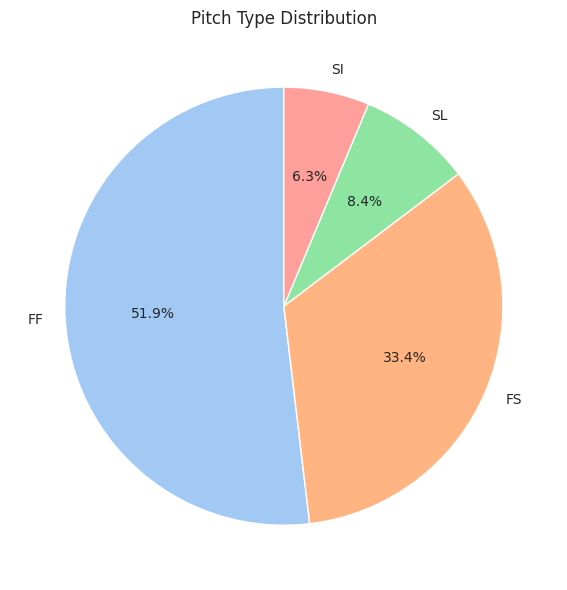

In [7]:
# exploratory visualization

sns.set_style("white")
plt.figure(figsize=(6, 6))
colors = sns.color_palette("pastel", 4)
plt.pie(
    pitches_train['pitch_type'].value_counts(),
    labels=pitches_train['pitch_type'].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Pitch Type Distribution")
plt.tight_layout()
plt.show()

Here we can see the distribution of pitch type in the training dataset is skewed towards 4-Seam Fastballs and Split-Finger pitches.

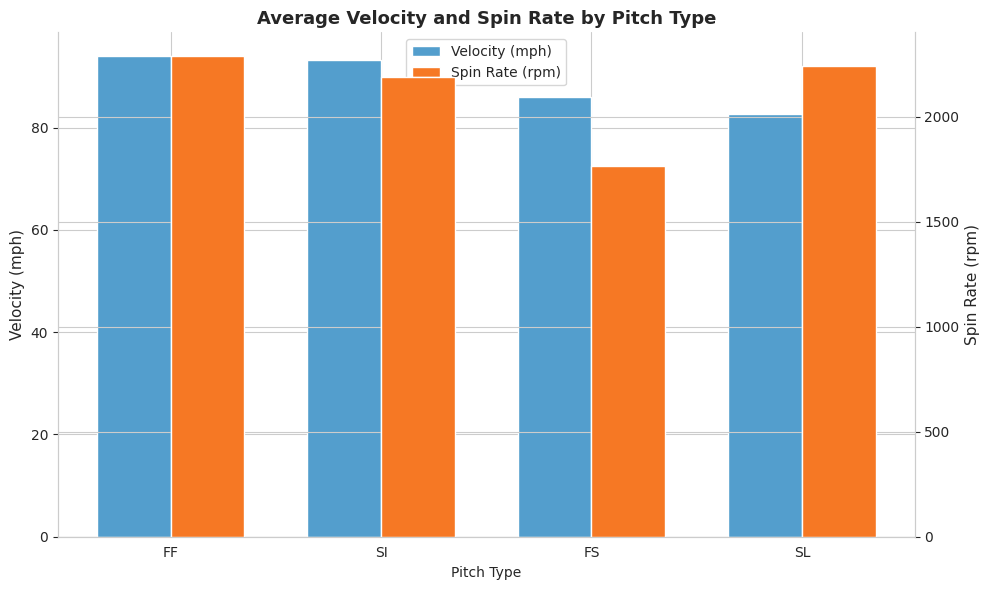

In [8]:
summary = (
    pitches_train
    .groupby("pitch_type")[["release_speed", "release_spin_rate"]]
    .mean()
    .reset_index()
)

summary = summary.sort_values("release_speed", ascending=False)

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(summary))
width = 0.35

bars1 = ax1.bar(
    x - width/2,
    summary["release_speed"],
    width,
    label="Velocity (mph)",
    color=sns.color_palette("Blues")[3]
)

ax1.set_ylabel("Velocity (mph)", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(summary["pitch_type"])
ax1.set_xlabel("Pitch Type")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width/2,
    summary["release_spin_rate"],
    width,
    label="Spin Rate (rpm)",
    color=sns.color_palette("Oranges")[3]
)

ax2.set_ylabel("Spin Rate (rpm)", fontsize=11)

plt.title("Average Velocity and Spin Rate by Pitch Type", fontsize=13, weight="bold")

bars = bars1 + bars2
labels = [b.get_label() for b in [bars1, bars2]]
ax1.legend([bars1, bars2], labels, loc="upper center")

sns.despine(left=False, right=False)
plt.tight_layout()
plt.show()

Here we can see how velocity and spin rate compare by pitch. This makes it clearer to see that 4-Seam Fastball is the fastest and has the highest rpm, while Split-Finger has the lowest rpm.

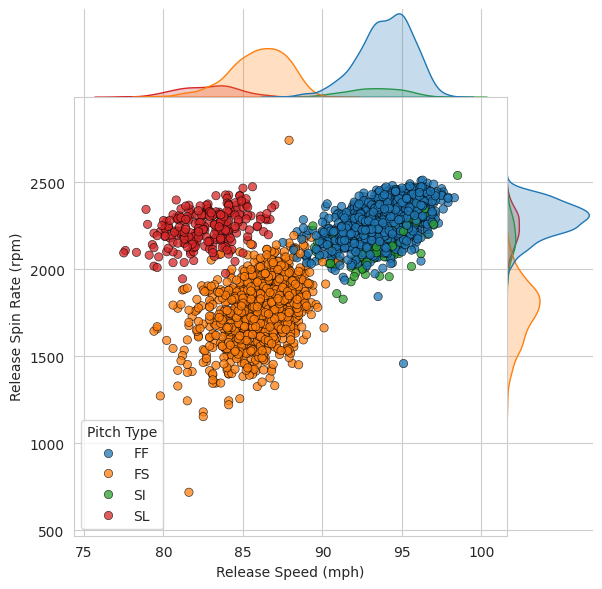

In [9]:
plot = sns.jointplot(
    data=pitches_train,
    x="release_speed",
    y="release_spin_rate",
    hue="pitch_type",
    edgecolor="k",
    alpha=0.75,
    space=0,
)
plot.set_axis_labels(
    xlabel="Release Speed (mph)",
    ylabel="Release Spin Rate (rpm)",
)
plot.ax_joint.legend(
    title="Pitch Type",
    loc="lower left",
)
plt.title("Pitch Distribution Release Speed and Spin Rate")
plt.show()

This shows how a classification model has promise to predict pitch type by the six features we have, with just 2 features showing clear clusters (groups) emerging.

### Models

In [10]:
# process data for ML
# create X and y for train
X_train = pitches_train.drop("pitch_type", axis=1)
y_train = pitches_train["pitch_type"]

# create X and y for test
X_test = pitches_test.drop("pitch_type", axis=1)
y_test = pitches_test["pitch_type"]

The data is split into what we're trying to predict (target variable) and what we're using to predict it (feature variables). We do this for both the data we're training the model on and the data we're testing our final model on.

In [11]:
cols = pitches_train.columns

In [12]:
numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # ("encoder", OneHotEncoder())
        ("OneHotEncoder", OneHotEncoder(handle_unknown="infrequent_if_exist"))
    ] 
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_transformer, cols[1:5].tolist()),
        ("categorical", categorical_transformer, ['stand'])    
    ],
    remainder='drop'
)
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)

This creates a procedure to preprocess the independent variable (feature) data before we put it into the model. There is a different procedure depending on whether the data is categorical (batting stance) or numerical (release speed, spin rate, horizontal movement, vertical movement). These two procedures are combined to make an overall process for cleaning up the data. 

There are a few significant operations being performed on the data. The first one is filling in missing values (imputing). For numerical data, we are just plugging in the median value of the associated variable, but for categorical data, we are plugging in the most frequent. The second operation is scaling. Different variables have different standard deviations, so for numerical variables we scale it, so the mean is 0 and the standard deviation is 1. This ensures that a variable won't have an outsized impact on the model due to the nature of its variance. We also encode the categorical data, assigning 0s and 1s depending on the value, making it numerically processable.

Finally, we assign what process we want done to what columns, with 'Stand' (batting stance) getting the categorical process and everything else getting the numerical process. We then combine this preprocessor with the type of classifier model we want to use (KNeighborsClassifier) to create an overall pipeline for our model.

In [13]:
param_grid = {
    "classifier__n_neighbors": list(range(1,60,2)),
    "classifier__p": [1,2],
    "classifier__weights": ["uniform", "distance"],
    "preprocessor__numeric__scaler": [None, StandardScaler()]
}

mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

mod.fit(X_train, y_train)

Next, we select a range of parameters we want to test on for our model. This includes how flexible we want to model to be, how we measure distance between datapoints, and how we weight those distances.

Then, we will try making a model with every possible combination of the metrics we give it, within the range we give it, and have it return the one with the highest accuracy. 

## Results

In [14]:
# report model metrics
pprint(mod.best_params_)
pprint(mod.best_score_)

{'classifier__n_neighbors': 51,
 'classifier__p': 2,
 'classifier__weights': 'uniform',
 'preprocessor__numeric__scaler': StandardScaler()}
np.float64(0.9811712911444748)


The accuracy of the best model was 98.12%. The specific metrics of our best model are as follows:
p=2
n_neighbors=51
weights=uniform

In [15]:
test_accuracy = mod.score(X_test, y_test)
test_accuracy

0.9861572535991141

The test accuracy of our final model was 98.62%, meaning it successfully predicted 96.62% of the pitch types.

In [16]:
y_test.value_counts()

pitch_type
FF    967
FS    693
SL    144
SI      2
Name: count, dtype: int64

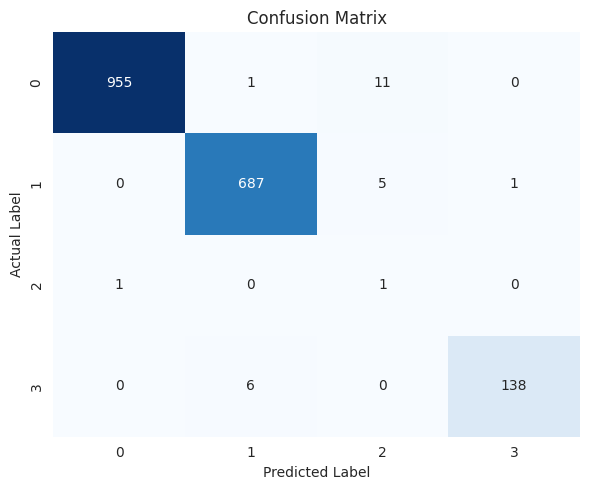

In [17]:
cm = confusion_matrix(y_test, mod.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

This is a confusion matrix that shows how the models predictions for individual pitch types stack up against the actual values. The test dataset only had a few sinker pitches, and we can see that it was highly accurate for all pitch types, making it usable in a game setting. To be safe, one may consider testing it on a dataset that includes many sinker pitches as well.
1: 4-Seam Fastball
2: Split-Finger
3: Sinker
4: Slider

In [18]:
# serialize model
dump(mod, "pitches.joblib")

['pitches.joblib']

Finally, we will serialize the model by using the dump() function, making the model sharable.

## Discussion

In conclusion, I would strongly consider deploying this model in practice, with appropriate safeguards. The primary benefit is that it provides immediate pitch identification to fans in the stadium and at home. By labeling pitches in real time, the model adds instant context for casual viewers who may struggle to distinguish between similar offerings such as cutters and sliders. This reduces ambiguity, enhances broadcast clarity, and allows viewers to better understand sequencing, pitcher tendencies, and in-game strategy.

However, there are meaningful limitations. The model was trained and evaluated using data from a single pitcher, Kevin Gausman, which raises concerns about generalizability. Pitch characteristics vary significantly across pitchers, meaning a global model may struggle with individualized arsenals. A more robust approach would likely require either pitcher-specific models or a larger, more diverse training dataset.

Additionally, model performance is highly dependent on accurate tracking inputs such as velocity, spin rate, and movement data. Any measurement error or latency in these inputs would directly reduce classification accuracy. There is also potential for concept drift, as pitchers adjust grips, mechanics, or pitch mixes over time, requiring periodic retraining to maintain performance.

Despite these limitations, if high-quality tracking data is available and the model is continuously updated, implementing a live pitch classification system would likely provide meaningful value to both casual and analytically inclined viewers.
